# Análise do Risco de Crédito

In [20]:
# importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# biblioteca de machine learning
from sklearn.model_selection import train_test_split # holdout
from sklearn.preprocessing import StandardScaler # padronização
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict

In [ ]:
# lendo a base
# link para o dataset : https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk
df_credit = pd.read_csv('')

### Descrição dos dados - German Credit Data

| Column Name         | Description |
|---------------------|-------------|
| **Age**              | Age of the individual (in years). |
| **Sex**              | Gender of the individual (`male` or `female`). |
| **Job**              | Categorical variable indicating job status:<br>0: Unskilled and non-resident<br>1: Unskilled and resident<br>2: Skilled<br>3: Highly skilled |
| **Housing**          | Type of housing: `own`, `rent`, or `free`. |
| **Saving accounts**  | Approximate savings status:<br>May include `little`, `moderate`, `quite rich`, `rich`, or missing values (`NaN`). |
| **Checking account** | Balance of checking account:<br>May include `little`, `moderate`, `rich`, or missing values (`NaN`). |
| **Credit amount**    | Total credit amount requested/granted (in monetary units). |
| **Duration**         | Duration of the loan in months. |
| **Purpose**          | Purpose of the loan, such as:<br>`radio/TV`, `education`, `furniture/equipment`, `car`, etc. |
| **Risk**             | Credit risk classification:<br>`good` = low risk, `bad` = high risk. |





In [22]:
df_credit.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


## Análise Exploratória

In [23]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


* Coluna Unnamed: 0 pode ser excluída
* Variáveis categóricas: Sex, Housing, Saving accounts, Checking account, Purpose, Risk
* Variáveis numéricas: Age, Job, Duration, Credit amount
* Colunas Saving accounts e Checking account apresenta valores nulos então serão removidas

In [24]:
# removendo colunas indesejadas
df_credit.drop(['Unnamed: 0','Saving accounts','Checking account'],axis=1,inplace=True)

In [25]:
# checando se há valor duplicado
df_credit.duplicated().sum()

np.int64(0)

In [26]:
# verificando os valores presentes em cada coluna
for c in df_credit.columns:
  print(f'{c}: {df_credit[c].unique()}')

Age: [67 22 49 45 53 35 61 28 25 24 60 32 44 31 48 26 36 39 42 34 63 27 30 57
 33 37 58 23 29 52 50 46 51 41 40 66 47 56 54 20 21 38 70 65 74 68 43 55
 64 75 19 62 59]
Sex: ['male' 'female']
Job: [2 1 3 0]
Housing: ['own' 'free' 'rent']
Credit amount: [ 1169  5951  2096  7882  4870  9055  2835  6948  3059  5234  1295  4308
  1567  1199  1403  1282  2424  8072 12579  3430  2134  2647  2241  1804
  2069  1374   426   409  2415  6836  1913  4020  5866  1264  1474  4746
  6110  2100  1225   458  2333  1158  6204  6187  6143  1393  2299  1352
  7228  2073  5965  1262  3378  2225   783  6468  9566  1961  6229  1391
  1537  1953 14421  3181  5190  2171  1007  1819  2394  8133   730  1164
  5954  1977  1526  3965  4771  9436  3832  5943  1213  1568  1755  2315
  1412 12612  2249  1108   618  1409   797  3617  1318 15945  2012  2622
  2337  7057  1469  2323   932  1919  2445 11938  6458  6078  7721  1410
  1449   392  6260  7855  1680  3578  7174  2132  4281  2366  1835  3868
  1768   781  1924

In [27]:
df_credit.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


Informações relevantes:

*   Idade: mínimo 19 anos e máximo 75 anos, com média de 35,5 anos
*   Duração: mínimo 4 máximo de 72 anos, com média de 20,9
*   Valor do crédito: mínimo de 250 e máximo de 18424, com média de 3271,3




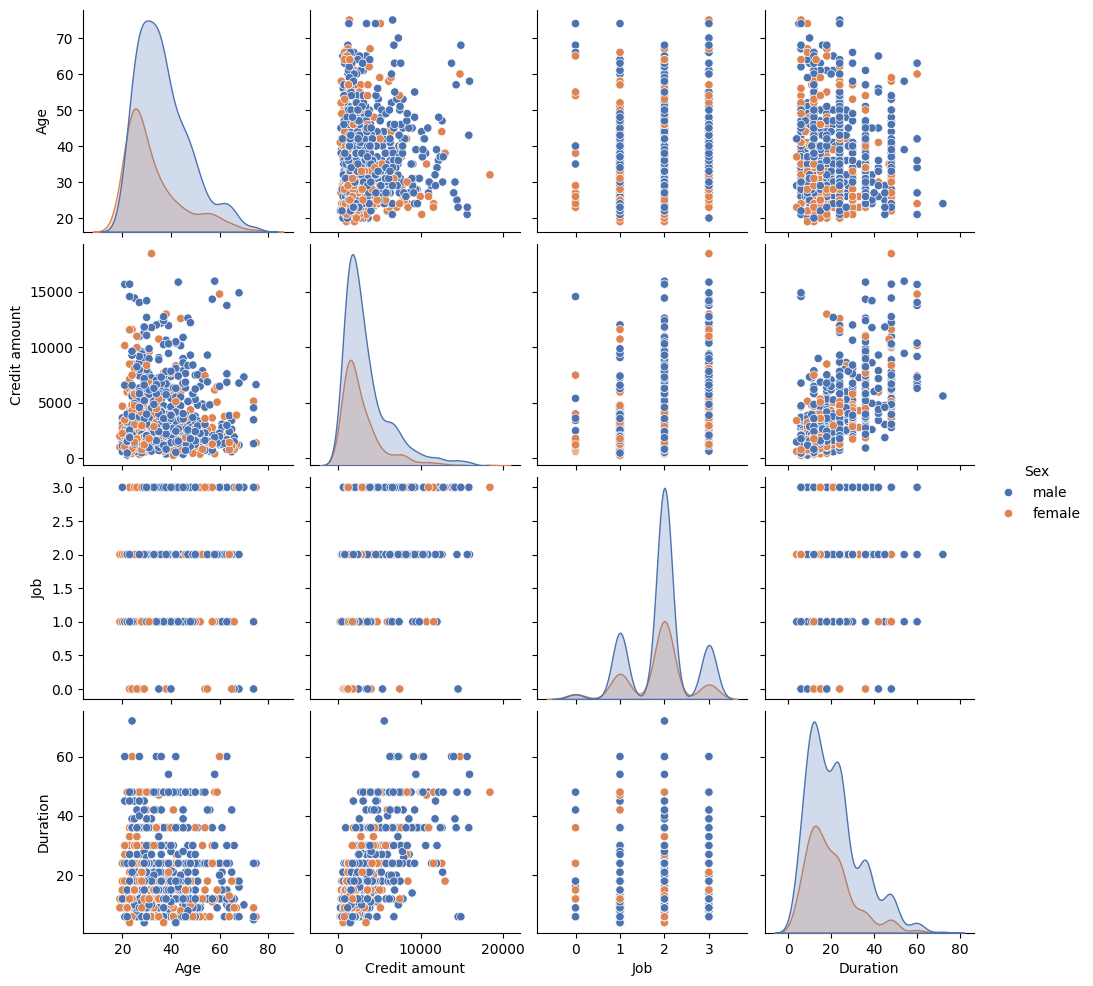

In [28]:
# verificando correlação
sns.pairplot(df_credit[['Sex','Age','Credit amount','Job','Duration']],hue='Sex',palette='deep')
plt.show()

In [29]:
df_credit[['Age','Credit amount','Job','Duration']].corr()

,Age,Credit amount,Job,Duration
Age,1.000000,0.032716,0.015673,-0.036136
Credit amount,0.032716,1.000000,0.285385,0.624984
Job,0.015673,0.285385,1.000000,0.210910
Duration,-0.036136,0.624984,0.210910,1.000000


Observação:
* As variáveis de Credit Amount e Duration tem uma correlação positiva e acima de 50%. Isto indica que a medida que o valor de crédito aumenta, o tempo de pagamento do empréstimo também aumenta.

### Perguntas e visualizações


*   Como está a distribuição de homens e mulheres?
*   Como é a classificação de acordo com o sexo e risco de crédito?
*   Como é a distribuição da idade por sexo?
*   Distribuição do valor de crédito por sexo
*   Quantidade de pessoas por objetivo/profissão
*   Total de crédito pelo próposito e sexo



In [30]:
import plotly.offline as offline

# distribuição por sexo
df_sex_viz = df_credit.groupby("Sex")["Age"].count().reset_index().rename(columns={"Age":"Quantidade","Sex":"Sexo"})

# grafico
fig = px.bar(df_sex_viz,x="Sexo",y="Quantidade",color="Sexo",color_discrete_map={
                 'male': '#1f77b4',  # azul
                 'female': '#e377c2'    # rosa
             },text_auto=True)

fig.update_traces(
    textposition='outside',   # Posiciona os valores acima das barras
    textfont=dict(size=14, color='black')  # Ajusta o tamanho e a cor da fonte
)

fig.update_layout(title='Distribuição de pessoas pelo sexo',
    xaxis=None,
    showlegend=False,
    plot_bgcolor='rgba(0,0,0,0)',    # fundo do gráfico transparente
    paper_bgcolor='rgba(0,0,0,0)',   # fundo externo transparente
    xaxis_title=None,
    yaxis_title=None,
    yaxis=dict(showticklabels=False),
    margin=dict(t=80))

offline.plot(fig, filename='grafico_1.html', auto_open=False)
fig.show()

In [31]:
# Porcentagem
df_female = df_credit[df_credit['Sex'] == "female"]
df_male = df_credit[df_credit['Sex'] == "male"]

#print(f"Porcentagem de mulheres: {df_female.shape[0]/df_credit.shape[0]*100:.2f}%")
#print(f"Porcentagem de homens: {df_male.shape[0]/df_credit.shape[0]*100:.2f}%")

df_perc = pd.DataFrame({"Sex":["female","male"],"Porcentagem":[df_female.shape[0]/df_credit.shape[0]*100,df_male.shape[0]/df_credit.shape[0]*100]})

fig = px.pie(df_perc,names="Sex",title="Porcentagem de homens e mulheres",values='Porcentagem')

fig.update_traces(
    textinfo='label+percent',
    hole=0.4,
    marker=dict(colors=['#e377c2','#1f77b4'])
)

fig.update_layout(
    showlegend=False)

offline.plot(fig, filename='grafico_2.html', auto_open=False)
fig.show()

Observação:
*  Existem mais homens do que mulheres indicando um desbalanceamento dos dados coletados

In [32]:
# sexo e risco de crédito

df_risco = df_credit.groupby(['Sex','Risk'])['Age'].count().reset_index().rename(columns={'Age':'Quantidade'})

fig = px.bar(
    df_risco,
    x='Sex',
    y='Quantidade',
    color='Risk',
    text='Quantidade',                # show value on bars
    title='Risco de crédito por sexo',
    barmode='stack'
)

fig.update_traces(textposition='inside')

fig.update_layout(
    showlegend=True,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    xaxis_title=None,
    yaxis_title=None,
    legend_title='Risco de crédito',
    yaxis=dict(showticklabels=False)
)

offline.plot(fig, filename='grafico_3.html', auto_open=False)
fig.show()

Observações:
* Temos mais pessoas com uma boa classificação de risco do que ruim.

In [33]:
# visualização da idade por sexo

fig = px.histogram(
    df_credit,
    x='Age',
    facet_col='Sex',                 # separa por sexo
    color = 'Sex',
    nbins=30,                     # número de intervalos (bins)
    title='Distribuição de Idade por Sexo'
)

fig.update_layout(
    title_text='Histograma de Idade por Sexo',
    showlegend=False,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(showticklabels=False)
)

offline.plot(fig, filename='grafico_4.html', auto_open=False)
fig.show()

Observações:
* Para os homens temos uma concentração maior de pessoas no intervalo de 20 a 40 anos
* Para as mulheres temos uma concentração maior entre 20 a 30 anos

In [34]:
# Visualizando a distribuição do propósito do crédito por sexo e total de crédito
df_purpose = df_credit.groupby(['Purpose', 'Sex'])['Credit amount'].sum().reset_index()
df_purpose = df_purpose.rename(columns={'Credit amount': 'Total de crédito'})

# Store absolute values for labels
df_purpose['Texto'] = df_purpose['Total de crédito'].apply(lambda x: f"{int(x):,}".replace(",", "."))

# Negate female values for mirrored effect
df_purpose['Total de crédito'] = df_purpose.apply(
    lambda row: -row['Total de crédito'] if row['Sex'] == 'female' else row['Total de crédito'],
    axis=1
)

# Plot
fig = px.bar(
    df_purpose,
    x='Total de crédito',
    y='Purpose',
    color='Sex',
    orientation='h',
    text='Texto',
    title='Total de crédito de acordo com o Propósito e Sexo (visualização espelhada)',
    color_discrete_map={
        'male': '#1f77b4',   # azul
        'female': '#e377c2'  # rosa
    }
)

# Clean layout
fig.update_layout(
    barmode='relative',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    xaxis=dict(visible=False),
    yaxis_title=None,
    xaxis_title=None,
)

offline.plot(fig, filename='grafico_5.html', auto_open=False)
fig.show()

Este gráfico indica que:
* as mulheres tendem a gastar mais com carros, equipamentos/móveis e rádio/tv já os homens tendem a utilizar o crédito para carro, radio/tv e equipamentos/móveis.
* Um ponto bem relevante é que para os homens temos um valor bem considerável sobre a utilização em negócios, sendo o 4º mais utilizado. Em contrapartida as mulheres não representam tanto neste propósito
* Os homens utilizam mais crédito para as férias do que mulheres

In [35]:
fig = px.violin(
    df_credit,
    y='Credit amount',
    x='Risk',
    color='Risk',
    box=True,               # show a boxplot inside the violin
    points='all',           # show all data points
    hover_data=df_credit.columns,
    title='Boxplot do valor de crédito por risco',
    color_discrete_map={
        'bad': '#d62728',
        'good': '#2ca02c'
    }
)

fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    xaxis_title=None,
    yaxis_title='Valor de crédito'
)

offline.plot(fig, filename='grafico_6.html', auto_open=False)
fig.show()


Observações:

* Grupo de risco Bad: tem valores de crédito mais variável e os casos mais altos. Isto pode indicar que valores maiores tem um risco maior.

* Grupo de risco Good: tem uma faixa de valores concentrada entre 0 a 5 mil. Poucos valores são dados acima de 10 mil

In [36]:
# Tempo de empréstimo e valor
df_tmp = df_credit.groupby(['Duration'])['Credit amount'].sum().reset_index().sort_values(by='Duration',ascending=True)

bins = [0, 12, 24, 36, 48, 60, float('inf')]
labels = ['0-12 anos', '12-24 anos', '24-36 anos', '36-48 anos', '48-60 anos', '60+ anos']

df_tmp['Duration_category'] = pd.cut(df_tmp['Duration'], bins=bins, labels=labels, right=True, include_lowest=True)

df_tmp = df_tmp.groupby(['Duration_category'])['Credit amount'].sum().reset_index().sort_values(by='Duration_category',ascending=False)

# 2. Encontrar a categoria com o maior valor
max_category = df_tmp.loc[df_tmp['Credit amount'].idxmax(), 'Duration_category']

# 3. Definir as cores
df_tmp['color'] = df_tmp['Duration_category'].apply(
    lambda x: 'crimson' if x == max_category else '#1E3F66'
)

fig = px.bar(
    df_tmp,
    x='Credit amount',
    y='Duration_category',
    color = 'color',
    text='Credit amount',
    category_orders={'Duration_category': labels},
    color_discrete_map='identity',
    orientation='h'
)

fig.update_layout(
    title='Total de crédito por tempo de empréstimo',
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    xaxis_title=None,
    yaxis_title=None,
    xaxis = dict(showticklabels=False),
    showlegend=False
)

offline.plot(fig, filename='grafico_7.html', auto_open=False)
fig.show()

/tmp/ipython-input-36-3863378987.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Observações:
* O maior montante de crédito se encontra na duração de 12 a 24 anos, seguido por 24 a 36 anos e 0 a 12 anos. Isto indica que as pessoas estão mais dispostas a realizar o pagamento do crédito em até 2 anos.



## Machine Learning

* No caso, serão dadas as informações para prever se é um risco bom ou ruim sobre o crédito ser disponibilizado ao cliente.

In [37]:
# transformando as colunas categóricas em numéricas

#sexo
df_credit['Sex'] = df_credit['Sex'].map({'male':1,'female':0})

df_credit['Risk'] = df_credit['Risk'].map({'good':0,'bad':1})

# para as colunas de housing e purpose será aplicado o onehotencoder

df_credit = pd.get_dummies(df_credit, columns=['Housing','Purpose'])

In [38]:
df_credit.head()

,Age,Sex,Job,Credit amount,Duration,Risk,Housing_free,Housing_own,Housing_rent,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,1,2,1169,6,0,False,True,False,False,False,False,False,False,True,False,False
1,22,0,2,5951,48,1,False,True,False,False,False,False,False,False,True,False,False
2,49,1,1,2096,12,0,False,True,False,False,False,False,True,False,False,False,False
3,45,1,2,7882,42,0,True,False,False,False,False,False,False,True,False,False,False
4,53,1,2,4870,24,1,True,False,False,False,True,False,False,False,False,False,False


Dividindo os dados em treino e teste (método HoldOut)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
                                      df_credit.drop(columns={'Risk'}),
                                      df_credit['Risk'],
                                      test_size=0.30, random_state=42)

In [40]:
print(f"Tamanho dos dados de treino: {X_train.shape}")
print(f"Tamanho dos dados de teste: {X_test.shape}")

Tamanho dos dados de treino: (700, 16)
Tamanho dos dados de teste: (300, 16)


In [41]:
X_test.head()

,Age,Sex,Job,Credit amount,Duration,Housing_free,Housing_own,Housing_rent,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
521,24,0,2,3190,18,False,True,False,False,False,False,False,False,True,False,False
737,35,1,1,4380,18,False,True,False,False,True,False,False,False,False,False,False
740,32,1,2,2325,24,False,True,False,False,True,False,False,False,False,False,False
660,23,1,2,1297,12,False,False,True,False,False,False,False,False,True,False,False
411,35,1,3,7253,33,False,True,False,False,True,False,False,False,False,False,False


### Padronização

In [42]:
scaler = StandardScaler()

scaler.fit(X_train)

# É passada apenas para os dados de features
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
X_train_scaled

array([[ 2.17938197,  0.68149479,  0.09581896, ..., -0.63688499,
        -0.15776625, -0.12038585],
       [ 0.31188474,  0.68149479,  1.62021152, ..., -0.63688499,
        -0.15776625, -0.12038585],
       [ 1.91259665, -1.46736265,  0.09581896, ..., -0.63688499,
        -0.15776625, -0.12038585],
       ...,
       [-0.75525653,  0.68149479,  0.09581896, ..., -0.63688499,
        -0.15776625, -0.12038585],
       [-0.93311341,  0.68149479,  0.09581896, ...,  1.5701422 ,
        -0.15776625, -0.12038585],
       [-1.02204185, -1.46736265,  0.09581896, ...,  1.5701422 ,
        -0.15776625, -0.12038585]])

In [44]:
X_test_scaled

array([[-1.02204185, -1.46736265,  0.09581896, ...,  1.5701422 ,
        -0.15776625, -0.12038585],
       [-0.04382902,  0.68149479, -1.4285736 , ..., -0.63688499,
        -0.15776625, -0.12038585],
       [-0.31061433,  0.68149479,  0.09581896, ..., -0.63688499,
        -0.15776625, -0.12038585],
       ...,
       [-1.37775561,  0.68149479,  0.09581896, ..., -0.63688499,
        -0.15776625, -0.12038585],
       [-0.04382902,  0.68149479,  1.62021152, ..., -0.63688499,
        -0.15776625, -0.12038585],
       [-1.37775561, -1.46736265,  0.09581896, ..., -0.63688499,
        -0.15776625, -0.12038585]])

### Feature Selection com Random Forest

In [45]:
clf = RandomForestClassifier()

clf.fit(X_train, y_train)

RandomForestClassifier()

In [46]:
# Obter a importância das características
importances = clf.feature_importances_

importances

array([0.23979178, 0.03352201, 0.0632433 , 0.30321149, 0.18246163,
       0.01751881, 0.02444479, 0.01401581, 0.01659608, 0.0255317 ,
       0.00675116, 0.01376187, 0.01904   , 0.02546748, 0.00875806,
       0.00588404])

In [47]:
df_credit.columns

Index(['Age', 'Sex', 'Job', 'Credit amount', 'Duration', 'Risk',
       'Housing_free', 'Housing_own', 'Housing_rent', 'Purpose_business',
       'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education',
       'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs',
       'Purpose_vacation/others'],
      dtype='object')

In [48]:
# Mostrar a importância das características
features = df_credit.drop(columns=['Risk'], axis=1).columns
for i, feature_name in enumerate(features):
    print(f'{feature_name}: {importances[i]:.4f}')

Age: 0.2398
Sex: 0.0335
Job: 0.0632
Credit amount: 0.3032
Duration: 0.1825
Housing_free: 0.0175
Housing_own: 0.0244
Housing_rent: 0.0140
Purpose_business: 0.0166
Purpose_car: 0.0255
Purpose_domestic appliances: 0.0068
Purpose_education: 0.0138
Purpose_furniture/equipment: 0.0190
Purpose_radio/TV: 0.0255
Purpose_repairs: 0.0088
Purpose_vacation/others: 0.0059


In [49]:
# Selecionar as top N características (por exemplo, as 2 mais importantes)
indices = np.argsort(importances)[::-1]
indices  # Ordenar as características pela importância

array([ 3,  0,  4,  2,  1,  9, 13,  6, 12,  5,  8,  7, 11, 14, 10, 15])

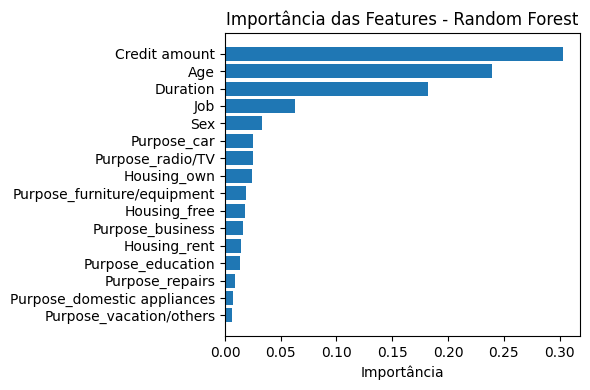

In [50]:
plt.figure(figsize=(6, 4))
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), [features[i] for i in indices])
plt.gca().invert_yaxis()
plt.xlabel("Importância")
plt.title("Importância das Features - Random Forest")
plt.tight_layout()
plt.show()

De acordo com a importância das features iremos escolher as 5 primeiras com maior valor para analisar como a acurácia se comporta.

In [51]:
top_n = 5
selected_features = indices[:top_n]

# Criar um novo conjunto de dados com as características selecionadas
X_train_selected = X_train.iloc[:, selected_features]
X_test_selected = X_test.iloc[:, selected_features]

# Treinar um novo modelo com as características selecionadas
clf_selected = RandomForestClassifier()
clf_selected.fit(X_train_selected, y_train)

# Avaliar o desempenho
accuracy = clf_selected.score(X_test_selected,y_test)
print(f'\nAcurácia com as características selecionadas: {accuracy:.2f}')


Acurácia com as características selecionadas: 0.66


### Knn

Será utilizado o Knn com e sem cross validation



**Hold-Out x Cross Validation**

| Aspecto                     | Hold-out                                   | cross\_val\_predict                                                            |
| --------------------------- | ------------------------------------------ | ------------------------------------------------------------------------------ |
| Divisão dos dados           | Uma vez (ex: 70/30)                        | Várias vezes (ex: 5 folds)                                                     |
| Treino e teste              | Modelo treinado em parte, testado no resto | Modelo treinado várias vezes em diferentes subconjuntos                        |
| Previsões obtidas           | Apenas no conjunto de teste (ex: 30%)      | Para **todas** as amostras (100%)                                              |
| Tamanho de `y_pred`         | Igual ao tamanho do `X_test`               | Igual ao tamanho total de `X`                                                  |
| Dados vistos durante treino | `X_train` apenas                           | Todos os dados, mas **nunca a mesma amostra no treino e teste ao mesmo tempo** |


In [52]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)

In [53]:
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

Analisando o resultado

Text(0.5, 1.0, 'Matriz de confusão dos dados de teste vs inferência do modelo')

<Figure size 1600x1200 with 0 Axes>

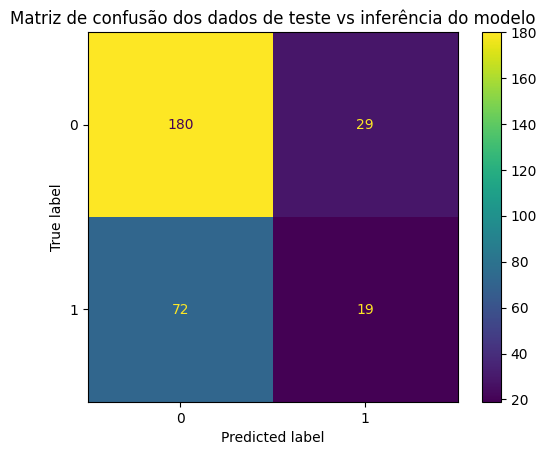

In [54]:
plt.figure(figsize = (16,12))
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=[0,1])
cmd.plot()
plt.title("Matriz de confusão dos dados de teste vs inferência do modelo")

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.86      0.78       209
           1       0.40      0.21      0.27        91

    accuracy                           0.66       300
   macro avg       0.56      0.54      0.53       300
weighted avg       0.62      0.66      0.63       300



In [56]:
knn.score(X=X_test_scaled, y=y_test)

0.6633333333333333

KNN com Cross Validation

In [57]:
# modelo knn
knn_cv = KNeighborsClassifier(n_neighbors=5)

# X = df_credit.drop(columns={'Risk'})
# y = df_credit['Risk']

X = np.concatenate((X_train_scaled,X_test_scaled))
y = np.concatenate((y_train,y_test))

cvs_score = cross_val_score(knn_cv, X,y,cv=5)

cvs_score

array([0.685, 0.64 , 0.705, 0.64 , 0.685])

In [58]:
print(np.average(cvs_score)*100)

67.10000000000001


Observação:
* A utilização do KNN sem o cross validation proporciona uma acurácia de 63% mas com a sua utilização ocorre um aumento para 67%

**Qual seria o melhor valor de K para utilizarmos juntamente com o cross validation? Ou seja que nos proporciona a melhor acurácia**

Text(0, 0.5, 'Score Rate')

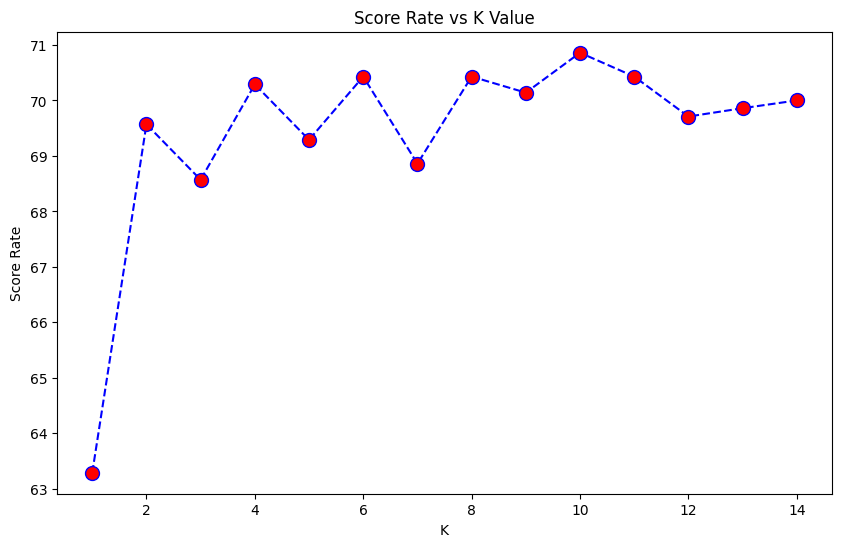

In [59]:
score = []

for i in range(1,15):
  #modelo
  knn = KNeighborsClassifier(n_neighbors=i)
  #cross validation
  cvs_score = cross_val_score(knn, X_train_scaled,y_train,cv=5)
  score.append(round((cvs_score.mean()*100), 2))

plt.figure(figsize=(10,6))
plt.plot(range(1,15), score, color='blue', linestyle='dashed', marker='o',
           markerfacecolor = 'red', markersize=10)
plt.title('Score Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Score Rate')

In [60]:
for i in range(1,15):
  print(f'k{i-1}:{score[i-1]}')

k0:63.29
k1:69.57
k2:68.57
k3:70.29
k4:69.29
k5:70.43
k6:68.86
k7:70.43
k8:70.14
k9:70.86
k10:70.43
k11:69.71
k12:69.86
k13:70.0


O melhor valor de k seria 9  que gera um score de 70,86%

In [61]:
# modelo knn para o melhor valor de K
knn_cv_best = KNeighborsClassifier(n_neighbors=9)

cvs_score = cross_val_score(knn_cv_best, X,y,cv=5)

cvs_score

array([0.725, 0.695, 0.695, 0.64 , 0.715])

In [62]:
y_cross_pred_cv = cross_val_predict(knn_cv_best,X,y)

In [63]:
print(classification_report(y, y_cross_pred_cv))

              precision    recall  f1-score   support

           0       0.72      0.93      0.81       700
           1       0.47      0.15      0.22       300

    accuracy                           0.69      1000
   macro avg       0.59      0.54      0.52      1000
weighted avg       0.64      0.69      0.63      1000



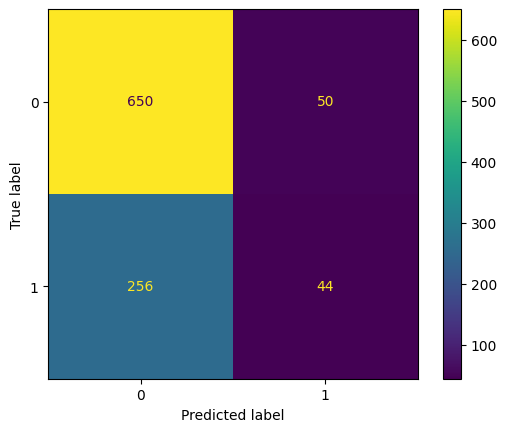

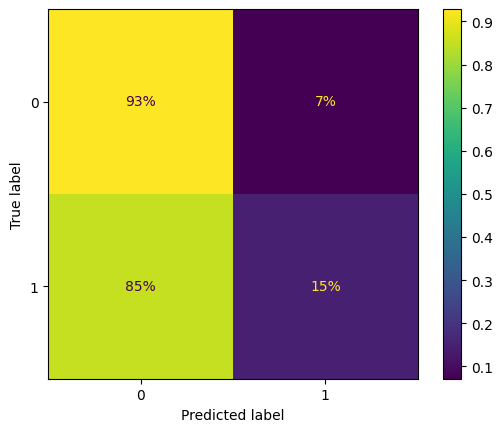

In [64]:
print(ConfusionMatrixDisplay.from_predictions(y, y_cross_pred_cv))
print(ConfusionMatrixDisplay.from_predictions(y, y_cross_pred_cv, normalize='true',values_format='.0%'))

### Gradient Boosting Classifier

In [65]:
# Gradient Boosting Classifier

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42)

gb_model.fit(X_train_scaled, y_train)

y_pred = gb_model.predict(X_test_scaled)

# 6. Avaliar
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia: {accuracy:.2f}')

Acurácia: 0.67


In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.89      0.79       209
           1       0.38      0.16      0.23        91

    accuracy                           0.67       300
   macro avg       0.55      0.53      0.51       300
weighted avg       0.61      0.67      0.62       300



<Figure size 1600x1200 with 0 Axes>

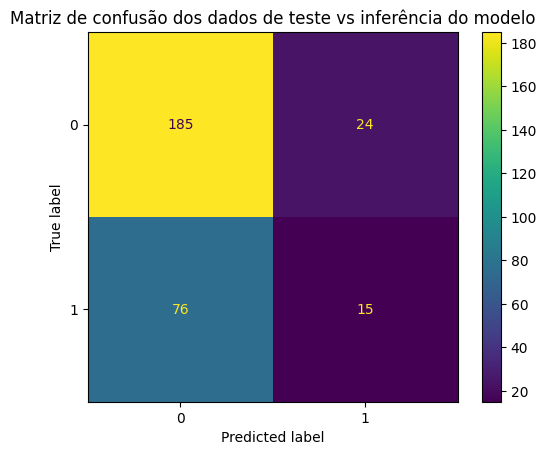

In [67]:
plt.figure(figsize = (16,12))
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=[0,1])
#cmd = ConfusionMatrixDisplay(cm, display_labels=y_test.unique())
cmd.plot()
plt.title("Matriz de confusão dos dados de teste vs inferência do modelo")
plt.show()

### Decision Tree Classifier

In [68]:
from sklearn import tree
from sklearn.metrics import classification_report
model = tree.DecisionTreeClassifier()

model.fit(X_train,y_train) # Cria a árvore baseada nos dados de treinamento
predictions = model.predict(X_test) # Prediz a saída dos dados de teste

# Avalia o modelo
print("Acurácia:", accuracy_score(y_test, predictions))
print("\nRelatório de Classificação:\n", classification_report(y_test, predictions))

Acurácia: 0.59

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.71      0.70      0.70       209
           1       0.33      0.34      0.34        91

    accuracy                           0.59       300
   macro avg       0.52      0.52      0.52       300
weighted avg       0.59      0.59      0.59       300



<Figure size 1600x1200 with 0 Axes>

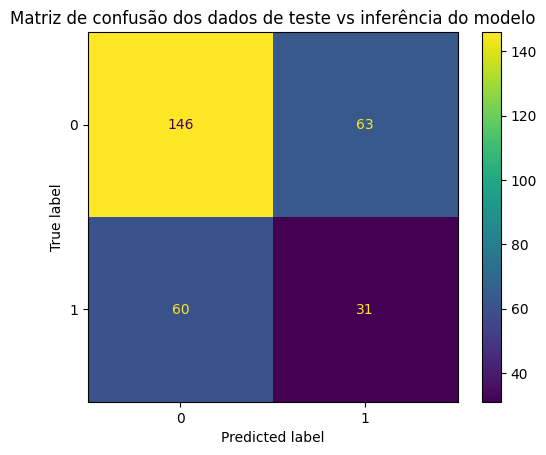

In [69]:
plt.figure(figsize = (16,12))
cm = confusion_matrix(y_test, predictions)
cmd = ConfusionMatrixDisplay(cm, display_labels=[0,1])
#cmd = ConfusionMatrixDisplay(cm, display_labels=y_test.unique())
cmd.plot()
plt.title("Matriz de confusão dos dados de teste vs inferência do modelo")
plt.show()

## Conclusões

* Análise Exploratória
    * Dados desbalanceados: maior incidência de casos do tipo de risco bom do que ruim
    * Crédito concedido durante o tempo de 12 a 24 meses
    * Maior concentração de perfis na faixa de 20 a 40 anos de idade
    * As mulheres tendem a gastar mais com carros, equipamentos/móveis e rádio/tv já os homens tendem a utilizar o crédito para carro, radio/tv e equipamentos/móveis.


* Machine Learning
   * Comparação do desempenho entre os modelos
      * Feature Selection com Random Forest nos indicou uma acurácia de 67% selecionando apenas as 5 primeiras features com maior importância
      * knn sem o cross validation apresentou 63% de acurácia e com o cross validation teve um aumento para 67%
      * Gradient Boosting apresentou 67% de acurácia
      * DecisionTree apresentou 59% de acurácia contudo teve o maior valor de acertos para o grupo classificado como ruim (30 de 91)  em comparação com os demais na aplicação dos dados separados por Hold-out.




